0.001034


(array([1.16131248e-05, 3.21894704e-04, 3.46324496e-03, 1.69681478e-02,
        3.58417982e-02, 3.31596942e-02, 1.33174036e-02, 2.30541642e-03,
        1.78736548e-04, 5.91213626e-06]),
 array([ 3.55581226, 13.02785376, 22.49989526, 31.97193677, 41.44397827,
        50.91601978, 60.38806128, 69.86010278, 79.33214429, 88.80418579,
        98.27622729]),
 <BarContainer object of 10 artists>)

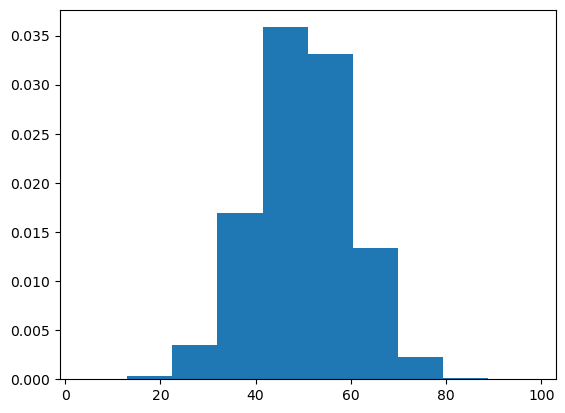

In [40]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)


# for a single nomral distro,, 10K is nuff but for joint probab where variables must fail simultaneously 1M is baseline
# as we might have undersampled the 'tail risks'

fa_samples= np.random.normal(loc=35, scale=5, size=1000000)

ucs_samples=np.random.normal(loc=50, scale=10, size=1000000)

rqd_samples = np.random.normal(loc=70, scale=15, size=1000000)

#in numpy neeed to use bitwise and
weak = ((ucs_samples<30) & (rqd_samples<50) & (fa_samples<35))
# as we provide more filters, our probab will decrease

probab_weak = weak.mean()
#using mean on a boolean array gives probability

arr = fa_samples[fa_samples<25]

#print(fa_samples)
#print(arr.mean())

print(probab_weak)


plt.hist(ucs_samples, density=True)


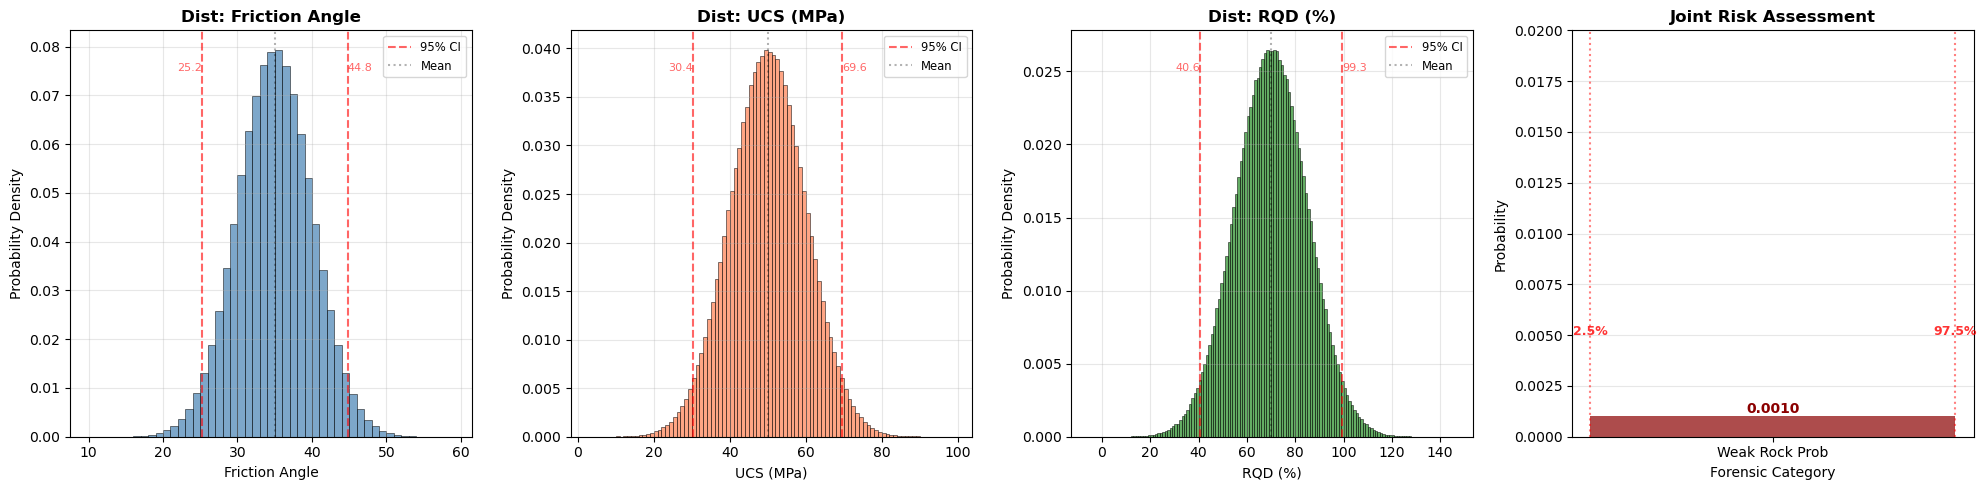

In [41]:
# Plotting the three distributions


# plotting with densiity true to standardizing area to 1 to make regional risk comparison possible, to not allow the actual value of data to change the physical truth (straight vs crooked thinking), can calc the actual risk percentage from graph like probab = density times bin width

# with bins = 50 we ordered to divide the range of entiere 1M samples to 50 equal slices which blurs the 'contractural' boundary

# freedman diaconis is a good default to find signal to noise ratio but for contractual


fig, axes = plt.subplots(1, 4, figsize=(20, 5))

data_sets = [
    (fa_samples, 'Friction Angle', 'steelblue'),
    (ucs_samples, 'UCS (MPa)', 'coral'),
    (rqd_samples, 'RQD (%)', 'forestgreen')
]

for idx, (data, title, color) in enumerate(data_sets):
    ax = axes[idx]

    #active_bins = 'fd'

    #Strict 1-unit physical resolution
    active_bins = np.arange(np.floor(data.min()), np.ceil(data.max()) + 1.0, 1.0)

    # Histogram with density and dynamic statistical binning
    ax.hist(data, bins=active_bins, density=True, alpha=0.7, color=color, edgecolor='black', linewidth=0.5)

    # Uncertainty: 95% Credible Interval (Safety Threshold)
    lower, upper = np.percentile(data, [2.5, 97.5])
    ax.axvline(lower, color='red', linestyle='--', alpha=0.6, label='95% CI')
    ax.axvline(upper, color='red', linestyle='--', alpha=0.6)

    # Minimalistic Mean line (Less noticeable than CI)
    ax.axvline(data.mean(), color='black', linestyle=':', alpha=0.3, label='Mean')

    # Minimal label for CDI boundaries
    ax.text(lower, ax.get_ylim()[1]*0.9, f'{lower:.1f}', color='red', alpha=0.6, ha='right', fontsize=8)
    ax.text(upper, ax.get_ylim()[1]*0.9, f'{upper:.1f}', color='red', alpha=0.6, ha='left', fontsize=8)

    ax.set_title(f'Dist: {title}', fontweight='bold')
    # CLEAN X-AXIS LABELS
    ax.set_xlabel(title)
    ax.set_ylabel('Probability Density')
    ax.legend(fontsize='small')
    ax.grid(alpha=0.3)

# 4th Plot: Combined forensic view of weak rock mass probability
bar = axes[3].bar(['Weak Rock Prob'], [probab_weak], color='darkred', alpha=0.7)

# Show probability value on top of the bar
axes[3].text(0, probab_weak, f'{probab_weak:.4f}', ha='center', va='bottom', fontweight='bold', color='darkred')

# Highlighting the boundaries of the 95% interval failure mode
# Adding vertical lines to enclose the 95% region
axes[3].axvline(-0.4, color='red', linestyle=':', alpha=0.5)
axes[3].axvline(0.4, color='red', linestyle=':', alpha=0.5)
axes[3].text(-0.4, 0.005, '2.5%', color='red', alpha=0.8, fontsize=9, fontweight='bold', ha='center')
axes[3].text(0.4, 0.005, '97.5%', color='red', alpha=0.8, fontsize=9, fontweight='bold', ha='center')

axes[3].set_title('Joint Risk Assessment', fontweight='bold')
axes[3].set_xlabel('Forensic Category')
axes[3].set_ylabel('Probability')
axes[3].set_ylim(0, 0.02)
axes[3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
## HOW TO KNOW EXACTLY HOW MANY BINS A FUNCTION MADE:
# 1. Pull the data from numpy using the same settings

sample = ucs_samples

# compare here bins = fd with bins = active bins
counts, edges = np.histogram(sample, bins='fd')
print(f"BINS CREATED by 'fd': {len(counts)}")

# 2. Probability from Graph vs Math (One-Liner Architecture)
threshold = 30
prob_math = (sample < threshold).mean()

# For a graph with density=True AND bin_width=1, probability is just the SUM of the heights (densities)
prob_graph = counts[edges[:-1] < threshold].sum() / len(sample) # Converting raw counts back to probability

print(f"Math: {prob_math:.4f} | Graph: {prob_graph:.4f}")

# 3. The Forensic Delta Check (One-Liner Variant)
delta = abs(prob_graph - prob_math)
print(f"Delta: {delta:.2e} -> {'[VALID]' if delta < 1e-10 else '[REJECTED: Graph Leaks Liability]'}")

# but is valid for active bins


BINS CREATED by 'fd': 352
Math: 0.0228 | Graph: 0.0239
Delta: 1.08e-03 -> [REJECTED: Graph Leaks Liability]
